## Növények növekedése – gyakorló adathalmaz

Egy biológiai vizsgálat során diákcsoport a növények növekedését követi nyomon.  
Az adathalmaz két független változót és egy célváltozót tartalmaz:

- **ido** – a napok száma, amióta a növények növekedésnek indultak  
- **talajnedvesseg** – a talaj nedvessége milliméterben  
- **magassag** – a növények magassága centiméterben  

A megfigyelések szerint a növények növekedése kezdetben gyors, majd lassul, ezért az **ido** változó másodfokú kapcsolatot mutat a magassággal.  
A talaj nedvessége lineárisan befolyásolja a növények magasságát, kisebb mértékben, mint az idő.

## 1. feladat – Adathalmaz betöltése

Olvassuk be a gyakorló adathalmazt a `novenyek.csv` fájlból

In [1]:
# 1. feladat – CSV beolvasása
import pandas as pd

# Adathalmaz beolvasása
df = pd.read_csv("novenyek.csv")

# Az első 5 sor megtekintése
df.head()

,ido,talajnedvesseg,magassag
0,0.248357,31.273938,8.825543
1,0.543113,84.175758,27.394985
2,1.548334,25.964051,11.319773
3,2.598250,98.950955,37.494166
4,2.331903,81.779582,28.337351


## 2. feladat – Lineáris regresszió az idő változóval

Készítsünk egy **lineáris regressziós modellt** az `ido` és a `magassag` változó között, majd vizualizáljuk az adatokat és az illesztett egyenest.  

Lineáris regresszió egyenes paraméterei:
Meredekség (theta1): 5.019
Y-metszet (theta0): 2.363


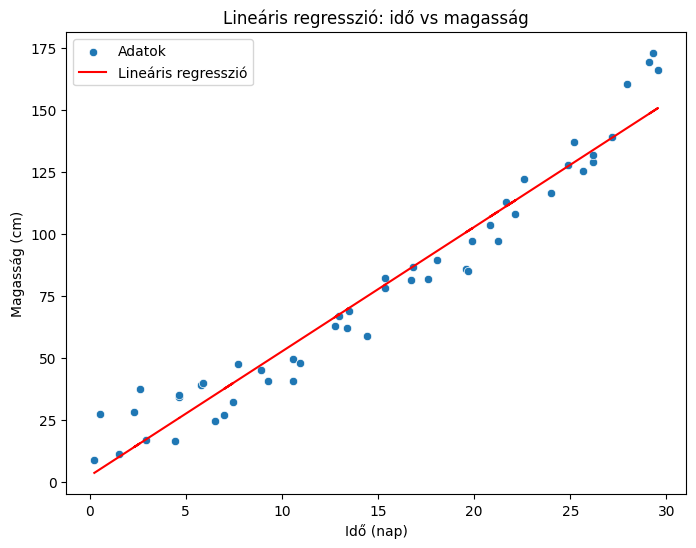

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression

# 2. feladat – Lineáris regresszió ido és magassag között
X = df[["ido"]]  # független változó
y = df["magassag"]  # célváltozó

# Lineáris modell létrehozása és betanítása
lin_model = LinearRegression()
lin_model.fit(X, y)

# Predikció az egyeneshez
y_pred = lin_model.predict(X)

# Eredmények
print("Lineáris regresszió egyenes paraméterei:")
print(f"Meredekség (theta1): {lin_model.coef_[0]:.3f}")
print(f"Y-metszet (theta0): {lin_model.intercept_:.3f}")

# Vizualizáció
plt.figure(figsize=(8, 6))
sns.scatterplot(x="ido", y="magassag", data=df, label="Adatok")
plt.plot(df["ido"], y_pred, color="red", label="Lineáris regresszió")
plt.xlabel("Idő (nap)")
plt.ylabel("Magasság (cm)")
plt.title("Lineáris regresszió: idő vs magasság")
plt.legend()
plt.show()

## 3. feladat – Modell értékelése R² segítségével

Számoljuk ki a lineáris regressziós modell **R² értékét** az `ido` és `magassag` változó között, majd jelenítsük meg a képernyőn.  

In [3]:
from sklearn.metrics import r2_score

# 3. feladat – R² számítása
r2 = r2_score(y, y_pred)
print(f"A lineáris regresszió R² értéke: {r2:.3f}")

A lineáris regresszió R² értéke: 0.949


## 4. feladat – Másodfokú polinom illesztése az idő változóra

Illesszünk egy **másodfokú polinomot** az `ido` és a `magassag` változó közé.  
Vizualizáljuk az adatokat és az illesztett polinom görbét, hogy lássuk a növekedés kezdeti gyorsaságát és a későbbi lassulást.

C:\Users\USER\anaconda3\envs\prog1\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


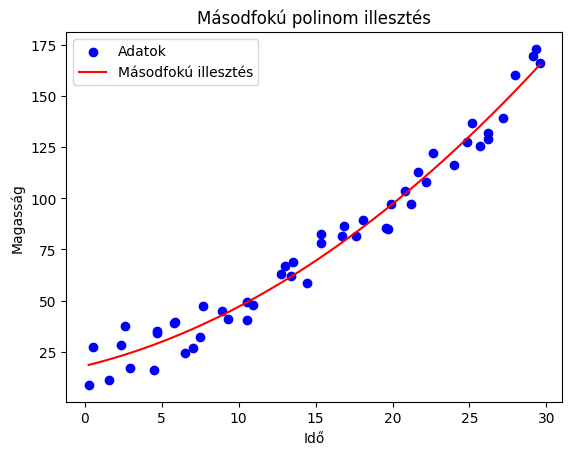

Polinom együtthatók (a*x^2 + b*x + c): 0.10640518591376757 1.8272341866712059 18.135606333930795
A lineáris regresszió R² értéke: 0.971


In [4]:
from sklearn.preprocessing import PolynomialFeatures


# 2. fokú polinom jellemzők előállítása
poly = PolynomialFeatures(degree=2)
ido_poly = poly.fit_transform(X)

# Lineáris regresszió a polinom jellemzőkkel
model = LinearRegression()
model.fit(ido_poly, y)

# Illesztett görbe előállítása
ido_fine = np.linspace(X.min(), X.max(), 50).reshape(-1, 1)
ido_fine_poly = poly.transform(ido_fine)
magassag_pred = model.predict(ido_fine_poly)

# Vizualizáció
plt.scatter(X, y, color='blue', label='Adatok')
plt.plot(ido_fine, magassag_pred, color='red', label='Másodfokú illesztés')
plt.xlabel('Idő')
plt.ylabel('Magasság')
plt.title('Másodfokú polinom illesztés')
plt.legend()
plt.show()

# Polinom együtthatók kiíratása
print("Polinom együtthatók (a*x^2 + b*x + c):", model.coef_[2], model.coef_[1], model.intercept_)

r2 = r2_score(y, magassag_pred)
print(f"A lineáris regresszió R² értéke: {r2:.3f}")